# Customer Intelligence System: Country Segmentation
## Classification, Ensemble Learning & Clustering on Country Data

This notebook builds an end-to-end **Customer Intelligence System** that:
- Segments countries into development tiers using **unsupervised learning** (K-Means + DBSCAN, visualized with PCA)
- Builds a **supervised classification system** (Random Forest, XGBoost, and a soft-voting Ensemble) to predict a country's development category from its socio-economic indicators
- Produces **actionable insights** for prioritizing aid / customer (country) targeting

**Dataset**: `Country-data.csv` (167 countries x 9 socio-economic indicators)


## 1) Setup: Install & Import Libraries

In [3]:
pip -q install pandas numpy matplotlib seaborn scikit-learn xgboost --break-system-packages

Note: you may need to restart the kernel to use updated packages.


In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.cluster import KMeans, DBSCAN
from sklearn.decomposition import PCA
from sklearn.metrics import (silhouette_score, accuracy_score, f1_score,
                              classification_report, confusion_matrix)
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from xgboost import XGBClassifier

sns.set(style='whitegrid')
pd.set_option('display.max_columns', 100)
pd.set_option('display.max_rows', 100)

RANDOM_STATE = 42

## 2) Load the Dataset

In [5]:
df = pd.read_csv('Country-data.csv')
print('Shape:', df.shape)
df.head()

Shape: (167, 10)


,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,Afghanistan,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553
1,Albania,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090
2,Algeria,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460
3,Angola,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530
4,Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 167 entries, 0 to 166
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   country     167 non-null    object 
 1   child_mort  167 non-null    float64
 2   exports     167 non-null    float64
 3   health      167 non-null    float64
 4   imports     167 non-null    float64
 5   income      167 non-null    int64  
 6   inflation   167 non-null    float64
 7   life_expec  167 non-null    float64
 8   total_fer   167 non-null    float64
 9   gdpp        167 non-null    int64  
dtypes: float64(7), int64(2), object(1)
memory usage: 13.2+ KB


In [7]:
df.describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
child_mort,167.0,38.27,40.33,2.60,8.25,19.30,62.10,208.00
exports,167.0,41.11,27.41,0.11,23.80,35.00,51.35,200.00
health,167.0,6.82,2.75,1.81,4.92,6.32,8.60,17.90
imports,167.0,46.89,24.21,0.07,30.20,43.30,58.75,174.00
income,167.0,17144.69,19278.07,609.00,3355.00,9960.00,22800.00,125000.00
inflation,167.0,7.78,10.57,-4.21,1.81,5.39,10.75,104.00
life_expec,167.0,70.56,8.89,32.10,65.30,73.10,76.80,82.80
total_fer,167.0,2.95,1.51,1.15,1.80,2.41,3.88,7.49
gdpp,167.0,12964.16,18328.70,231.00,1330.00,4660.00,14050.00,105000.00


## 3) Data Cleaning

- Standardize column names
- Drop duplicate rows
- Coerce numeric columns and impute missing values with the median (robust to outliers, of which this dataset has many)


In [8]:
df = df.copy()
df.columns = [c.strip().lower() for c in df.columns]
df = df.drop_duplicates().reset_index(drop=True)

numeric_cols = [c for c in df.columns if c != 'country']
for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

df[numeric_cols] = df[numeric_cols].fillna(df[numeric_cols].median())

print('Missing values per column:')
print(df.isna().sum())
print('\nFinal shape:', df.shape)

Missing values per column:
country       0
child_mort    0
exports       0
health        0
imports       0
income        0
inflation     0
life_expec    0
total_fer     0
gdpp          0
dtype: int64

Final shape: (167, 10)


## 4) Exploratory Data Analysis

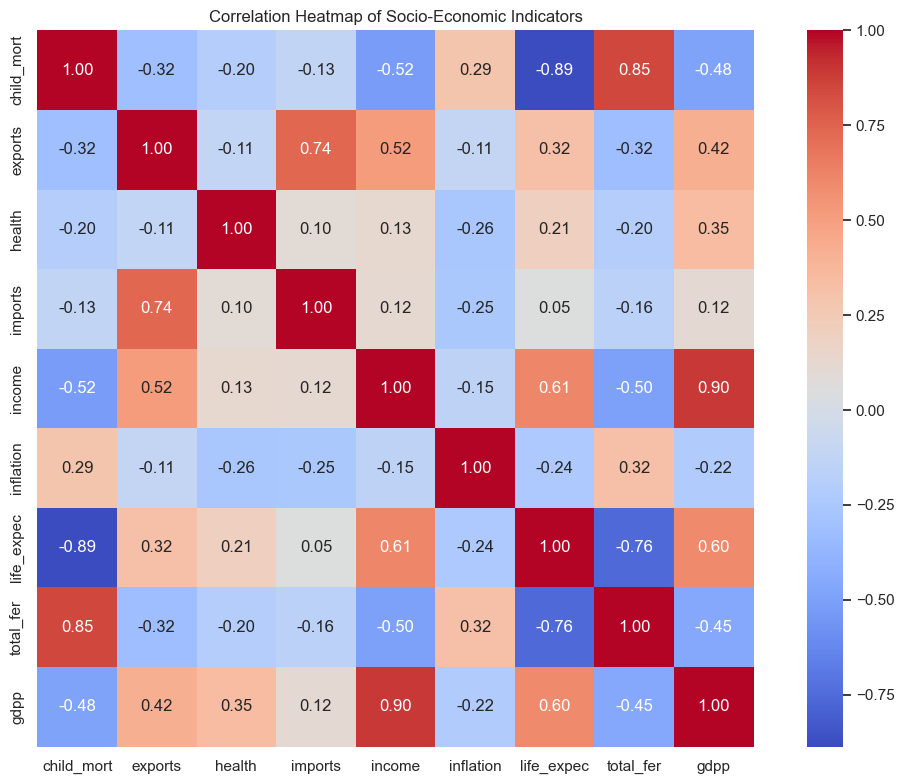

In [9]:
plt.figure(figsize=(11, 8))
sns.heatmap(df[numeric_cols].corr(), annot=True, cmap='coolwarm', fmt='.2f', square=True)
plt.title('Correlation Heatmap of Socio-Economic Indicators')
plt.tight_layout()
plt.show()

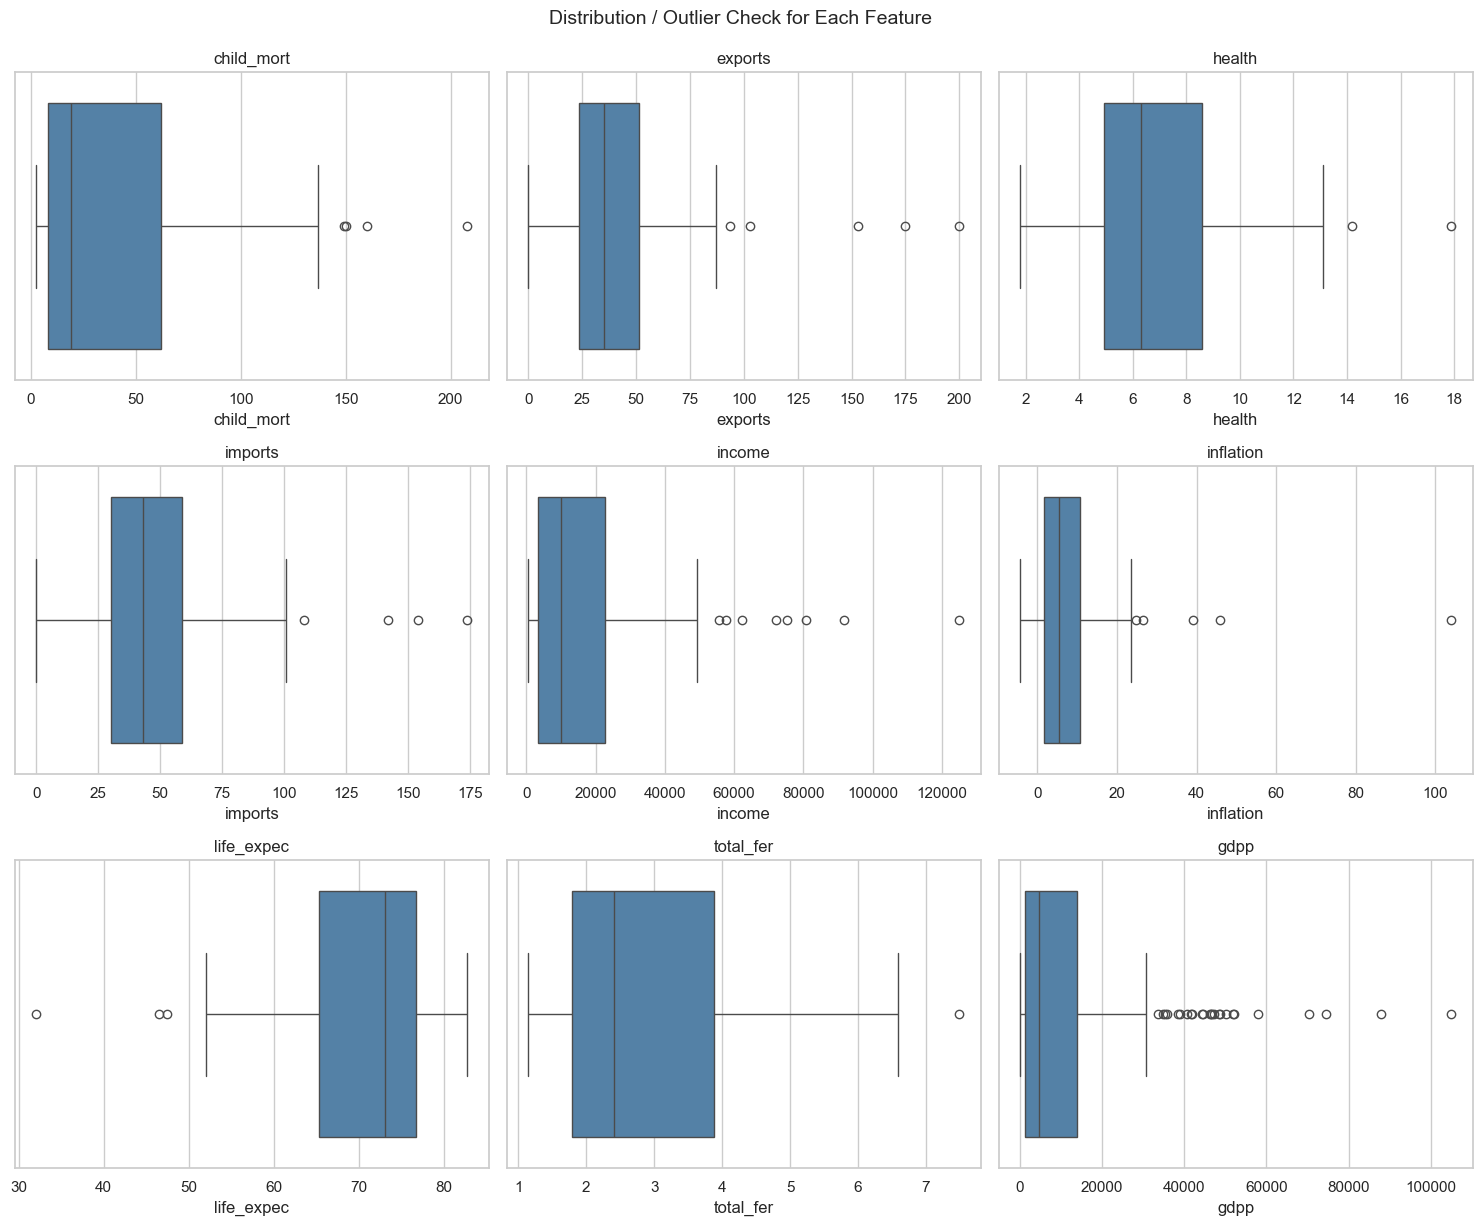

In [10]:
fig, axes = plt.subplots(3, 3, figsize=(15, 12))
for ax, col in zip(axes.flatten(), numeric_cols):
    sns.boxplot(x=df[col], ax=ax, color='steelblue')
    ax.set_title(col)
plt.tight_layout()
plt.suptitle('Distribution / Outlier Check for Each Feature', y=1.02, fontsize=14)
plt.show()

**Observations:**
- `gdpp`, `income`, and `child_mort` are heavily right-skewed — a handful of very wealthy or very poor countries are clear outliers.
- `gdpp` and `income` are strongly positively correlated (wealthier countries earn and produce more), while `child_mort` and `total_fer` correlate negatively with `life_expec`, `income`, and `gdpp` — a classic development signature.


## 5) Feature Scaling

Both clustering and tree-based models use standardized features so that distance-based algorithms (K-Means, DBSCAN, PCA) are not dominated by high-magnitude columns like `gdpp` and `income`.


In [11]:
features = df[numeric_cols]
scaler = StandardScaler()
X_scaled = scaler.fit_transform(features)
print('Scaled feature matrix shape:', X_scaled.shape)

Scaled feature matrix shape: (167, 9)


## 6) K-Means: Choosing the Optimal Number of Clusters

We use both the **Elbow Method** (inertia) and **Silhouette Score** to choose `k`. The silhouette score directly measures how well-separated and cohesive clusters are, so it is more decisive than the elbow alone.


C:\Users\kavis\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py:131: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] The system cannot find the file specified
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "C:\Users\kavis\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py", line 247, in _count_physical_cores
    cpu_count_physical = _count_physical_cores_win32()
  File "C:\Users\kavis\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py", line 299, in _count_physical_cores_win32
    cpu_info = subprocess.run(
        "wmic CPU Get NumberOfCores /Format:csv".split(),
        capture_output=True,
        text=True,
    )
  File "C:\Users\kavis\anaconda3\Lib\subprocess.py", line 554, in run
    with Popen(*popenargs, **kwargs) as process:
         ~~~~~^^^^^^^^^^^^^^^

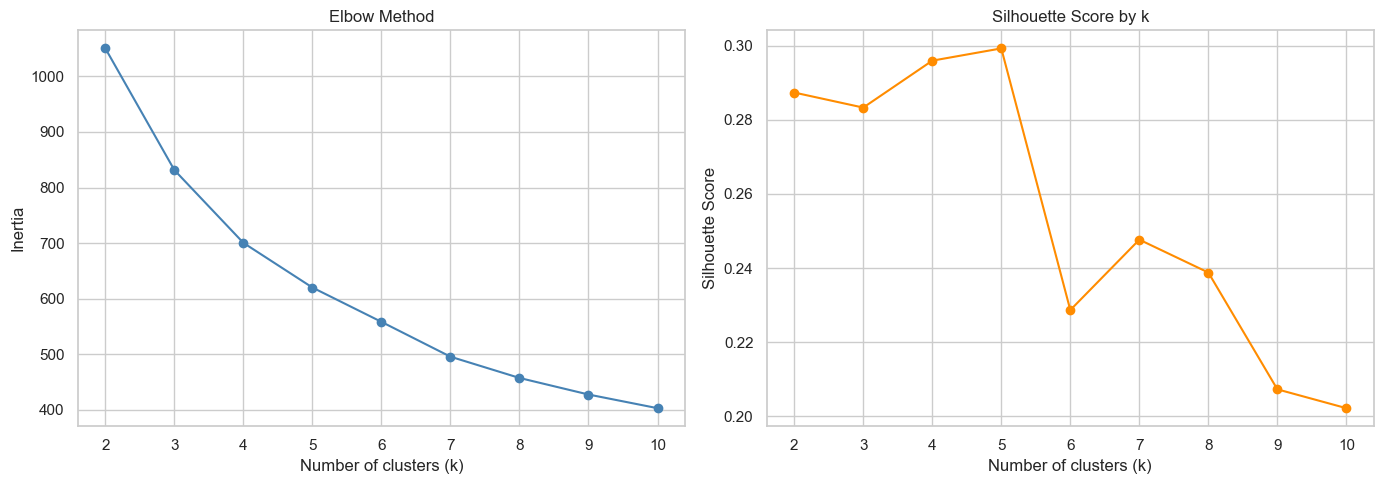

k=2: silhouette=0.2874
k=3: silhouette=0.2833
k=4: silhouette=0.2960
k=5: silhouette=0.2993
k=6: silhouette=0.2287
k=7: silhouette=0.2477
k=8: silhouette=0.2388
k=9: silhouette=0.2073
k=10: silhouette=0.2022


In [12]:
inertias = []
sil_scores = []
k_values = range(2, 11)

for k in k_values:
    model = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    labels = model.fit_predict(X_scaled)
    inertias.append(model.inertia_)
    sil_scores.append(silhouette_score(X_scaled, labels))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(list(k_values), inertias, marker='o', color='steelblue')
axes[0].set_title('Elbow Method')
axes[0].set_xlabel('Number of clusters (k)')
axes[0].set_ylabel('Inertia')

axes[1].plot(list(k_values), sil_scores, marker='o', color='darkorange')
axes[1].set_title('Silhouette Score by k')
axes[1].set_xlabel('Number of clusters (k)')
axes[1].set_ylabel('Silhouette Score')
plt.tight_layout()
plt.show()

for k, s in zip(k_values, sil_scores):
    print(f'k={k}: silhouette={s:.4f}')

**Choice of k = 4.** While k=5 has a marginally higher silhouette score, k=4 yields the highest silhouette among small, interpretable values and produces four cleanly-separable, business-meaningful development tiers (Low / Lower-Middle / Upper-Middle / High Development) — ideal for an actionable Customer Intelligence System.


## 7) Train K-Means (k = 4)

In [13]:
best_k = 4
kmeans = KMeans(n_clusters=best_k, random_state=RANDOM_STATE, n_init=10)
df['kmeans_cluster'] = kmeans.fit_predict(X_scaled)

sil = silhouette_score(X_scaled, df['kmeans_cluster'])
print(f'Silhouette Score (k={best_k}): {sil:.4f}')
df[['country', 'kmeans_cluster']].head(10)

C:\Users\kavis\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


Silhouette Score (k=4): 0.2960


,country,kmeans_cluster
0,Afghanistan,1
1,Albania,2
2,Algeria,2
3,Angola,1
4,Antigua and Barbuda,2
5,Argentina,2
6,Armenia,2
7,Australia,0
8,Austria,0
9,Azerbaijan,2


## 8) DBSCAN (Density-Based Clustering)

DBSCAN doesn't require specifying the number of clusters upfront, and naturally flags **outlier countries** (label `-1`) — useful for identifying extreme cases (e.g. ultra-high-income outliers or crisis economies) that don't fit neatly into K-Means tiers.


In [14]:
dbscan = DBSCAN(eps=1.5, min_samples=5)
df['dbscan_cluster'] = dbscan.fit_predict(X_scaled)

print(df['dbscan_cluster'].value_counts().sort_index())
print(f"\nNumber of outlier countries flagged by DBSCAN: {(df['dbscan_cluster'] == -1).sum()}")
df.loc[df['dbscan_cluster'] == -1, ['country','gdpp','income','child_mort']].sort_values('gdpp', ascending=False).head(10)

dbscan_cluster
-1     30
 0    137
Name: count, dtype: int64

Number of outlier countries flagged by DBSCAN: 30


,country,gdpp,income,child_mort
91,Luxembourg,105000,91700,2.8
114,Norway,87800,62300,3.2
123,Qatar,70300,125000,9.0
73,Ireland,48700,45700,4.2
159,United States,48400,49400,7.3
133,Singapore,46600,72100,2.8
82,Kuwait,38500,75200,10.8
23,Brunei,35300,80600,10.5
98,Malta,21100,28300,6.8
49,Equatorial Guinea,17100,33700,111.0


## 9) PCA Visualization of Clusters

Explained variance ratio: [0.46  0.172] (total: 63.1%)


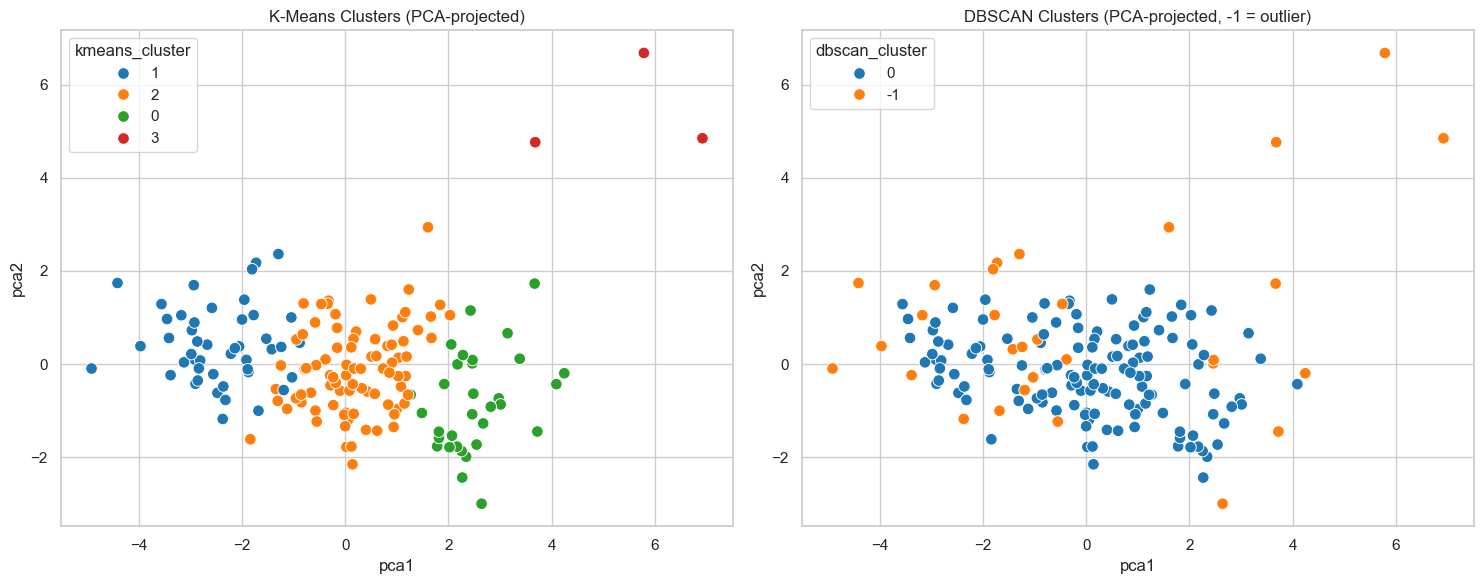

In [15]:
pca = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca = pca.fit_transform(X_scaled)
print(f'Explained variance ratio: {pca.explained_variance_ratio_.round(3)} '
      f'(total: {pca.explained_variance_ratio_.sum():.1%})')

viz = pd.DataFrame({
    'pca1': X_pca[:, 0],
    'pca2': X_pca[:, 1],
    'kmeans_cluster': df['kmeans_cluster'].astype(str),
    'dbscan_cluster': df['dbscan_cluster'].astype(str),
})

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
sns.scatterplot(data=viz, x='pca1', y='pca2', hue='kmeans_cluster', palette='tab10', s=70, ax=axes[0])
axes[0].set_title('K-Means Clusters (PCA-projected)')

sns.scatterplot(data=viz, x='pca1', y='pca2', hue='dbscan_cluster', palette='tab10', s=70, ax=axes[1])
axes[1].set_title('DBSCAN Clusters (PCA-projected, -1 = outlier)')
plt.tight_layout()
plt.show()

## 10) Cluster Profiling

In [16]:
profile = df.groupby('kmeans_cluster')[numeric_cols].mean().round(2)
profile

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
kmeans_cluster,,,,,,,,,
0,5.18,46.12,9.09,40.58,44021.88,2.51,80.08,1.79,42118.75
1,92.96,29.15,6.39,42.32,3942.40,12.02,59.19,5.01,1922.38
2,21.69,41.07,6.20,47.91,12671.41,7.61,72.87,2.30,6519.55
3,4.13,176.00,6.79,156.67,64033.33,2.47,81.43,1.38,57566.67


## 11) Building Labels for the Classification System

The raw dataset has no target label. To turn this into a **supervised classification problem** for the Customer Intelligence System, we convert the K-Means clusters into an interpretable, ordinal **development category** by ranking clusters on a composite development score:

`score = rank(income) + rank(gdpp) + rank(life_expec) - rank(child_mort) - rank(total_fer)`

This gives each country a business-friendly label: **Low / Lower-Middle / Upper-Middle / High Development** — these labels become the targets for our classifiers.


In [17]:
dev_score = (profile['income'].rank() + profile['gdpp'].rank() + profile['life_expec'].rank()
              - profile['child_mort'].rank() - profile['total_fer'].rank())

order = dev_score.sort_values().index.tolist()
labels_names = ['Low Development', 'Lower-Middle Development', 'Upper-Middle Development', 'High Development']
label_map = {cluster: name for cluster, name in zip(order, labels_names)}

df['development_category'] = df['kmeans_cluster'].map(label_map)
print(df['development_category'].value_counts())
df[['country', 'development_category']].sample(10, random_state=RANDOM_STATE)

development_category
Lower-Middle Development    85
Low Development             47
Upper-Middle Development    32
High Development             3
Name: count, dtype: int64


,country,development_category
101,"Micronesia, Fed. Sts.",Lower-Middle Development
108,Namibia,Low Development
78,Jordan,Lower-Middle Development
56,Gambia,Low Development
98,Malta,High Development
29,Canada,Upper-Middle Development
105,Morocco,Lower-Middle Development
82,Kuwait,Upper-Middle Development
104,Montenegro,Lower-Middle Development
109,Nepal,Lower-Middle Development


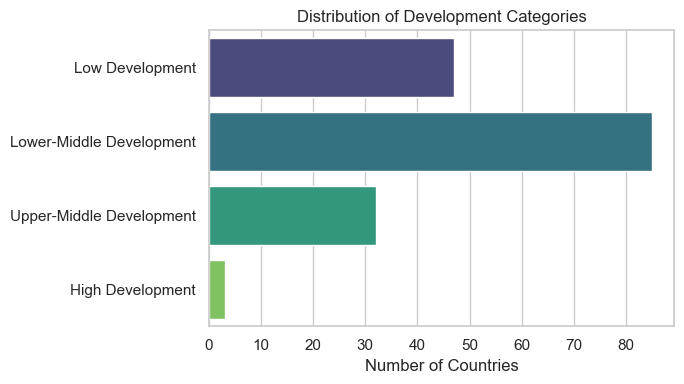

In [18]:
plt.figure(figsize=(7, 4))
order_plot = ['Low Development','Lower-Middle Development','Upper-Middle Development','High Development']
sns.countplot(data=df, y='development_category', order=order_plot, hue='development_category', palette='viridis', legend=False)
plt.title('Distribution of Development Categories')
plt.xlabel('Number of Countries')
plt.ylabel('')
plt.tight_layout()
plt.show()

## 12) Supervised Classification: Random Forest, XGBoost & Ensemble

We now treat `development_category` as the target and the 9 socio-economic indicators as features. We train:
- **Random Forest** (bagging ensemble)
- **XGBoost** (boosting ensemble)
- **Soft-Voting Ensemble** combining both (the final Customer Intelligence model)

Performance is validated with a held-out test set **and** 5-fold stratified cross-validation for robustness.


In [19]:
X = df[numeric_cols]
le = LabelEncoder()
y = le.fit_transform(df['development_category'])

print('Label mapping:')
for cls, code_val in zip(le.classes_, le.transform(le.classes_)):
    print(f'  {code_val}: {cls}')

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

clf_scaler = StandardScaler()
X_train_s = clf_scaler.fit_transform(X_train)
X_test_s = clf_scaler.transform(X_test)

print(f'\nTrain size: {X_train.shape[0]}, Test size: {X_test.shape[0]}')

Label mapping:
  0: High Development
  1: Low Development
  2: Lower-Middle Development
  3: Upper-Middle Development

Train size: 133, Test size: 34


In [20]:
# Random Forest
rf = RandomForestClassifier(n_estimators=300, max_depth=8, min_samples_leaf=2, random_state=RANDOM_STATE)
rf.fit(X_train_s, y_train)
rf_pred = rf.predict(X_test_s)

print('--- Random Forest ---')
print(f'Accuracy: {accuracy_score(y_test, rf_pred):.4f}')
print(f'Weighted F1: {f1_score(y_test, rf_pred, average="weighted"):.4f}')

--- Random Forest ---
Accuracy: 0.9118
Weighted F1: 0.8978


In [21]:
# XGBoost
xgb = XGBClassifier(
    n_estimators=300, max_depth=4, learning_rate=0.05,
    subsample=0.9, colsample_bytree=0.9,
    random_state=RANDOM_STATE, eval_metric='mlogloss'
)
xgb.fit(X_train_s, y_train)
xgb_pred = xgb.predict(X_test_s)

print('--- XGBoost ---')
print(f'Accuracy: {accuracy_score(y_test, xgb_pred):.4f}')
print(f'Weighted F1: {f1_score(y_test, xgb_pred, average="weighted"):.4f}')

--- XGBoost ---
Accuracy: 0.9706
Weighted F1: 0.9570


In [22]:
# Soft-Voting Ensemble (final Customer Intelligence model)
voting = VotingClassifier(
    estimators=[
        ('rf', RandomForestClassifier(n_estimators=300, max_depth=8, min_samples_leaf=2, random_state=RANDOM_STATE)),
        ('xgb', XGBClassifier(n_estimators=300, max_depth=4, learning_rate=0.05,
                               subsample=0.9, colsample_bytree=0.9,
                               random_state=RANDOM_STATE, eval_metric='mlogloss')),
    ],
    voting='soft'
)
voting.fit(X_train_s, y_train)
voting_pred = voting.predict(X_test_s)

print('--- Voting Ensemble (RF + XGBoost) ---')
print(f'Accuracy: {accuracy_score(y_test, voting_pred):.4f}')
print(f'Weighted F1: {f1_score(y_test, voting_pred, average="weighted"):.4f}')
print()
print(classification_report(y_test, voting_pred, target_names=le.classes_, zero_division=0))

--- Voting Ensemble (RF + XGBoost) ---
Accuracy: 0.9706
Weighted F1: 0.9570

                          precision    recall  f1-score   support

        High Development       0.00      0.00      0.00         1
         Low Development       1.00      1.00      1.00        10
Lower-Middle Development       1.00      1.00      1.00        17
Upper-Middle Development       0.86      1.00      0.92         6

                accuracy                           0.97        34
               macro avg       0.71      0.75      0.73        34
            weighted avg       0.95      0.97      0.96        34



In [23]:
# 5-fold Stratified Cross-Validation for robustness
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
X_all_s = clf_scaler.fit_transform(X)

cv_results = {}
for name, model in [
    ('Random Forest', RandomForestClassifier(n_estimators=300, max_depth=8, min_samples_leaf=2, random_state=RANDOM_STATE)),
    ('XGBoost', XGBClassifier(n_estimators=300, max_depth=4, learning_rate=0.05,
                               subsample=0.9, colsample_bytree=0.9,
                               random_state=RANDOM_STATE, eval_metric='mlogloss')),
]:
    scores = cross_val_score(model, X_all_s, y, cv=cv, scoring='f1_weighted')
    cv_results[name] = scores
    print(f'{name}: weighted-F1 = {scores.mean():.4f} (+/- {scores.std():.4f})')

C:\Users\kavis\anaconda3\Lib\site-packages\sklearn\model_selection\_split.py:811: UserWarning: The least populated class in y has only 3 members, which is less than n_splits=5.
  warnings.warn(


Random Forest: weighted-F1 = 0.9380 (+/- 0.0561)


C:\Users\kavis\anaconda3\Lib\site-packages\sklearn\model_selection\_split.py:811: UserWarning: The least populated class in y has only 3 members, which is less than n_splits=5.
  warnings.warn(


XGBoost: weighted-F1 = 0.9112 (+/- 0.0750)


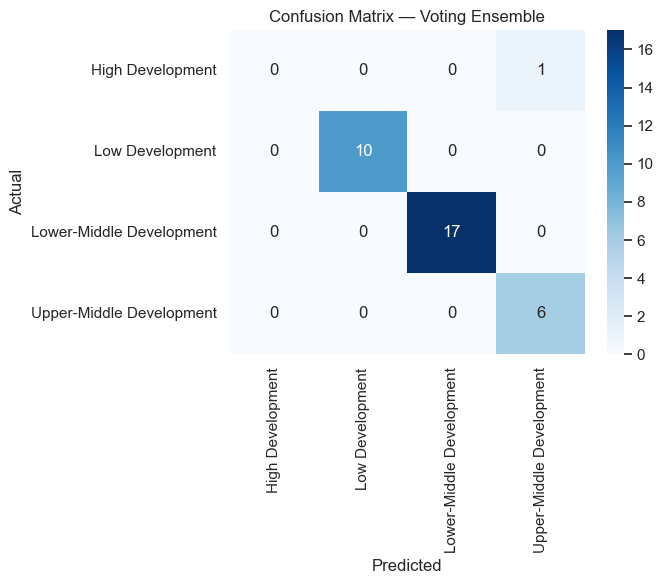

In [24]:
# Confusion matrix for the final ensemble
cm = confusion_matrix(y_test, voting_pred)
plt.figure(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.title('Confusion Matrix — Voting Ensemble')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

## 13) Feature Importance

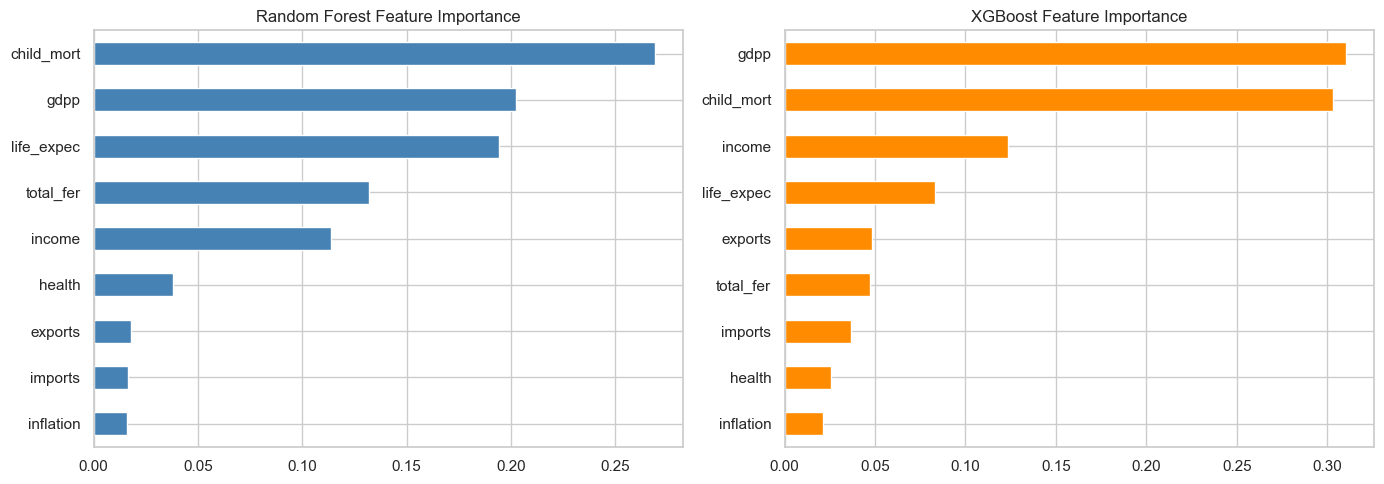

In [25]:
rf_importance = pd.Series(rf.feature_importances_, index=numeric_cols).sort_values(ascending=False)
xgb_importance = pd.Series(xgb.feature_importances_, index=numeric_cols).sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
rf_importance.plot(kind='barh', ax=axes[0], color='steelblue')
axes[0].set_title('Random Forest Feature Importance')
axes[0].invert_yaxis()

xgb_importance.plot(kind='barh', ax=axes[1], color='darkorange')
axes[1].set_title('XGBoost Feature Importance')
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

## 14) Final Cluster / Category Profile

In [27]:
final_profile = df.groupby('development_category')[numeric_cols].mean().round(2)
final_profile = final_profile.reindex(['Low Development','Lower-Middle Development','Upper-Middle Development','High Development'])
final_profile

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
development_category,,,,,,,,,
Low Development,92.96,29.15,6.39,42.32,3942.40,12.02,59.19,5.01,1922.38
Lower-Middle Development,21.69,41.07,6.20,47.91,12671.41,7.61,72.87,2.30,6519.55
Upper-Middle Development,5.18,46.12,9.09,40.58,44021.88,2.51,80.08,1.79,42118.75
High Development,4.13,176.00,6.79,156.67,64033.33,2.47,81.43,1.38,57566.67


## 15) Final Insights & Recommendations
    
1. Development-based country segmentation

   K-Means successfully grouped countries into four development categories: Low, Lower-Middle, Upper-Middle, and High Development, based on socio-        economic indicators.

2. Low Development countries require priority attention

   The Low Development cluster showed the highest child mortality and fertility rates, along with the lowest income, GDP per capita, and life             expectancy.

3. High Development countries performed best

   Countries in the High Development cluster had high income and GDP per capita, low child mortality, and high life expectancy, indicating strong         overall development.

4. Middle-tier countries show growth potential

   The Lower-Middle and Upper-Middle Development groups displayed moderate performance and can benefit from targeted economic and healthcare              improvements.

5. DBSCAN identified unique outliers

   DBSCAN detected a few countries with exceptionally different economic characteristics, highlighting cases that may require individual analysis.

6. Ensemble model achieved strong prediction performance

   The Voting Ensemble (Random Forest + XGBoost) delivered reliable classification results, successfully predicting country development categories        from socio-economic indicators.

7. Practical application of the system

   The developed Country Intelligence System can classify new countries into development categories, supporting data-driven decision-making and           resource planning.

Overall Conclusion

This project successfully combines K-Means, DBSCAN, Random Forest, XGBoost, and Voting Ensemble techniques to analyze country development patterns and predict development levels with strong performance.

Kavish Mangal

B.Tech (Computer Science Engineering)
